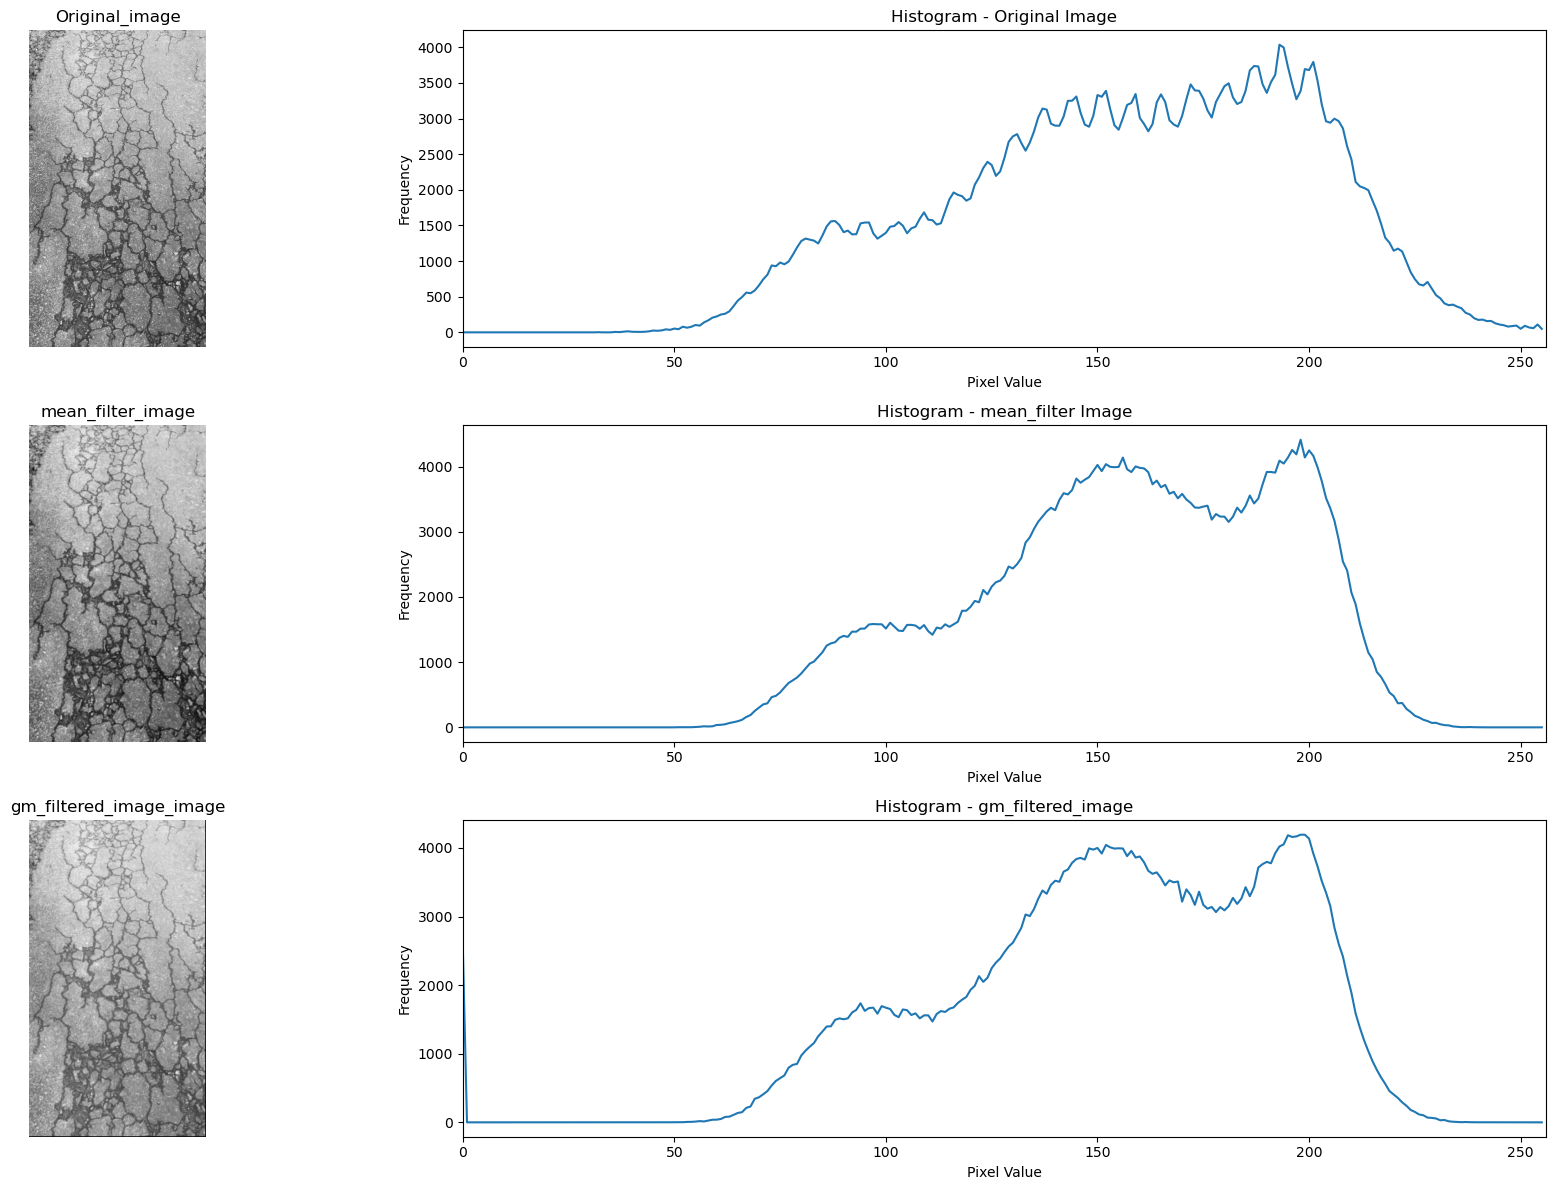

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_mean_filter(image, kernel_size):
    filtered_image = None 
    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size ** 2)
    filtered_image = cv2.filter2D(image, -1, kernel)
    return filtered_image

def apply_geometric_mean_filter(image, kernel_size):
    
    img_float = image.astype(float)
    pad_size = kernel_size // 2
    
    padded_img = np.pad(img_float, pad_size, mode='reflect')
    filtered_image = np.zeros_like(padded_img)
    
    for i in range(pad_size, padded_img.shape[0] - pad_size):
        for j in range(pad_size, padded_img.shape[1] - pad_size):
            kernel = padded_img[i-pad_size:i+pad_size+1, j-pad_size:j+pad_size+1]
            product = np.prod(kernel)
            filtered_image[i-pad_size, j-pad_size] = product**(1/(kernel_size**2))
    
    filtered_image = np.clip(filtered_image, 0, 255)
    filtered_image = filtered_image.astype(np.uint8)    
    return filtered_image

def plot_histogram(image, title):
    """Plot histogram of the given image."""
    histogram = cv2.calcHist([image], [0], None,[256], [0, 256])
    
    plt.title(title)
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.plot(histogram)
    plt.xlim([0, 256])

input_folder = "Frames"
output_folder = "Result"

image_path = input_folder + "/frame_0.jpg"
image = cv2.imread(image_path)

if image is None:
    print("Image not found!")

else:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mean_filter = apply_mean_filter(gray,3)
    gm_filtered_image = apply_geometric_mean_filter(gray, 3)
    
    plt.figure(figsize=(20,12))

    plt.subplot(3,2,1)
    plt.imshow(gray,cmap='gray')
    plt.axis("off")
    plt.title("Original_image")
    
    plt.subplot(3,2,2)
    plot_histogram(gray, "Histogram - Original Image")
    
    plt.subplot(3,2,3)
    plt.imshow(mean_filter,cmap='gray')
    plt.axis("off")
    plt.title("mean_filter_image")
    
    plt.subplot(3,2,4)
    plot_histogram(mean_filter, "Histogram - mean_filter Image")

    plt.subplot(3,2,5)
    plt.imshow(gm_filtered_image,cmap='gray')
    plt.axis("off")
    plt.title("gm_filtered_image_image")
    
    plt.subplot(3,2,6)
    plot_histogram(gm_filtered_image, "Histogram - gm_filtered_image")
    
    plt.tight_layout()

    cv2.imwrite(output_folder + "/original_gray.jpg", gray)
    cv2.imwrite(output_folder + "/mean_filter.jpg", mean_filter)
    cv2.imwrite(output_folder + "/gm_filtered.jpg", gm_filtered_image)
        